<a href="https://colab.research.google.com/github/nanthini-1990/GitHubWorkshop/blob/main/Exploratory_Data_Analysis_of_Retail_Sales_Dataset_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)

data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

# Outliers
data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)

print(df.shape)
df.head()

(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [3]:
# Task 1 — Inspect & Handle Missing Values
# Shape
df.shape



(200, 6)

In [4]:
#Data Types
df.dtypes



,0
order_id,int64
city,object
category,object
order_value,float64
delivery_days,float64
rating,object


In [5]:
# Missing Values Count
df.isnull().sum()



,0
order_id,0
city,0
category,0
order_value,14
delivery_days,10
rating,32


In [6]:
# Missing Value Percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.round(2)

,0
order_id,0.0
city,0.0
category,0.0
order_value,7.0
delivery_days,5.0
rating,16.0


In [7]:
# Summary & Visualization
df.describe()

,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


1. The order_value column has a very high maximum compared to the 75th percentile, indicating the presence of extreme outliers.
2. The delivery_days column shows moderate variation, but the mean and median are relatively close, suggesting a fairly balanced distribution.

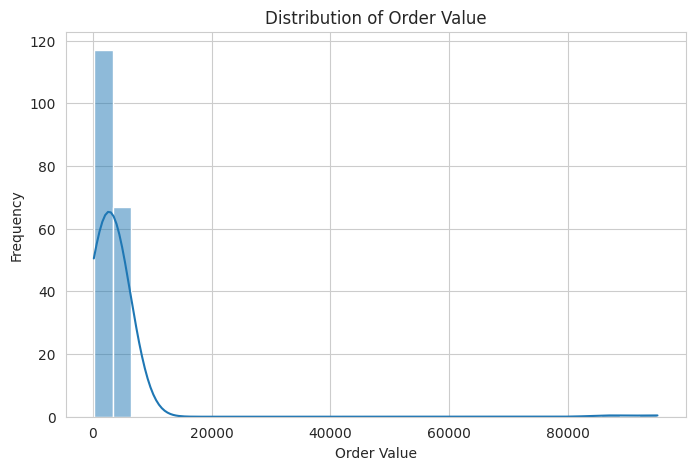

In [8]:
# Histogram (order_value)
plt.figure(figsize=(8,5))

sns.histplot(df["order_value"], bins=30, kde=True)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.show()

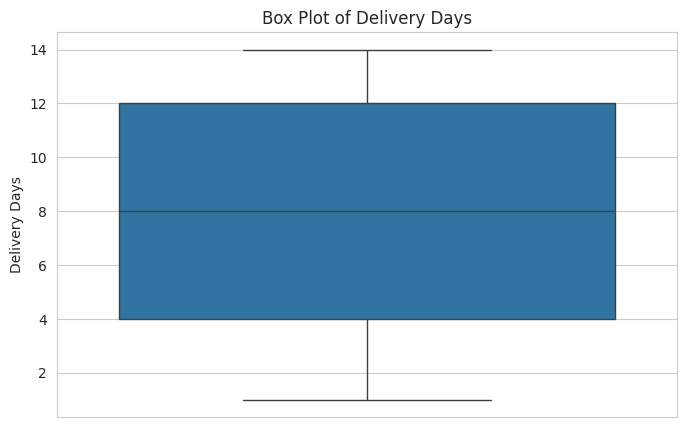

In [9]:
# Box Plot (delivery_days)
plt.figure(figsize=(8,5))

sns.boxplot(y=df["delivery_days"])

plt.title("Box Plot of Delivery Days")
plt.ylabel("Delivery Days")

plt.show()

In [10]:
# Correlation Analysis
corr = df.corr(numeric_only=True)
corr

,order_id,order_value,delivery_days
order_id,1.000000,-0.095503,0.004858
order_value,-0.095503,1.000000,0.141660
delivery_days,0.004858,0.141660,1.000000


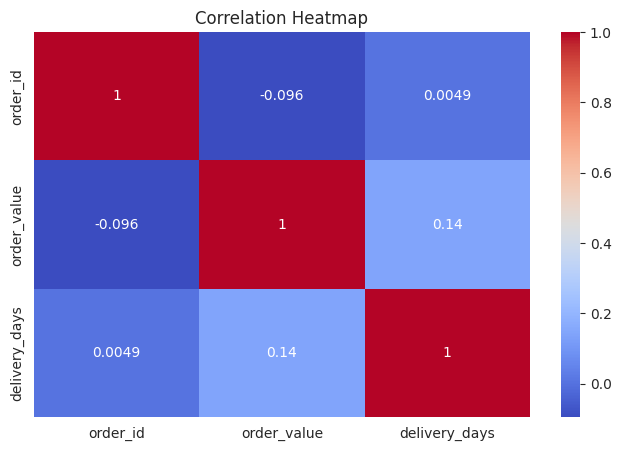

In [11]:
# Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

There is a weak positive relationship between order_value and delivery_days, suggesting that larger orders may take slightly more time for delivery. However, the correlation is not very strong.